In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aliyachomo/plant-villegedataset/label_num_to_disease_map.json
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train.csv
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test.csv
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1235188286.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1563395006.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1589421421.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1877332484.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/2319781928.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/3682266975.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/2780925336.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1551899349.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/277623554

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


2026-05-15 16:58:06.993593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778864287.214224      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778864287.278047      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778864287.809765      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778864287.809807      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778864287.809810      57 computation_placer.cc:177] computation placer alr

In [3]:
# =========================================================
# 3. IMPORT LIBRARIES
# =========================================================

import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

warnings.filterwarnings('ignore')

In [4]:
import os

for dirname, dirs, files in os.walk('/kaggle/input/datasets/aliyachomo/plant-villegedataset/'):
    print("FOLDER:", dirname)

    for file in files[:5]:
        print("   ", file)

    print("-" * 50)

FOLDER: /kaggle/input/datasets/aliyachomo/plant-villegedataset/
    label_num_to_disease_map.json
    Train.csv
    Test.csv
--------------------------------------------------
FOLDER: /kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean
    1235188286.jpg
    1563395006.jpg
    1589421421.jpg
    1877332484.jpg
    2319781928.jpg
--------------------------------------------------
FOLDER: /kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean
    1058931181.jpg
    688489193.jpg
    3507045403.jpg
    137128883.jpg
    495897960.jpg
--------------------------------------------------


In [5]:
# =========================================================
# DATASET PATHS
# =========================================================

MAIN_DATASET_PATH = "/kaggle/input/datasets/aliyachomo/plant-villegedataset/"

TRAIN_CSV = MAIN_DATASET_PATH + "/Train.csv"
TEST_CSV = MAIN_DATASET_PATH + "/Test.csv"

TRAIN_DIR = MAIN_DATASET_PATH + "/Train_Images_clean"
TEST_DIR = MAIN_DATASET_PATH + "/Test_Images_clean"

LABEL_JSON = MAIN_DATASET_PATH + "/label_num_to_disease_map.json"

In [6]:
import os

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(TEST_CSV))
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.path.exists(LABEL_JSON))

True
True
True
True
True


In [7]:
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.head())
print(test_df.head())

               ID  Labels
0  1758913732.jpg       3
1  1241243048.jpg       0
2  3761100385.jpg       2
3  3055614106.jpg       3
4  2386589588.jpg       4
               ID  Labels
0  2595356168.jpg       3
1   794817264.jpg       0
2  4270972443.jpg       4
3  3540803278.jpg       0
4  2142522228.jpg       3


In [8]:
with open(LABEL_JSON, "r") as f:
    label_map = json.load(f)

print(label_map)

{'0': 'CBB', '1': 'CBSD', '2': 'CGM', '3': 'CMD', '4': 'Healthy'}


In [9]:
train_df["Labels"] = train_df["Labels"].astype(int)
test_df["Labels"] = test_df["Labels"].astype(int)

num_classes = len(label_map)

print("Number of classes:", num_classes)
print("Train class count:")
print(train_df["Labels"].value_counts())

Number of classes: 5
Train class count:
Labels
3    800
0    800
2    800
4    800
1    800
Name: count, dtype: int64


In [10]:
print("Number of classes:", num_classes)

print("\nTotal images:")
print("Train:", len(train_df))
print("Test:", len(test_df))

print("\nClass distribution (Train):")
print(train_df["Labels"].value_counts())

Number of classes: 5

Total images:
Train: 4000
Test: 1000

Class distribution (Train):
Labels
3    800
0    800
2    800
4    800
1    800
Name: count, dtype: int64


In [11]:
import os

# Correct folders
train_dir = TRAIN_DIR

test_dir = TEST_DIR


# Function to count images
def count_images(folder):

    total = 0

    for root, dirs, files in os.walk(folder):

        images = [
            f for f in files
            if f.lower().endswith(
                ('.png', '.jpg', '.jpeg')
            )
        ]

        total += len(images)

    return total


# Print counts
print("✅ Total Train Clean Images:",
      count_images(train_dir))

print("✅ Total Test Clean Images:",
      count_images(test_dir))

✅ Total Train Clean Images: 4000
✅ Total Test Clean Images: 1000


In [12]:
# =========================================================
# COUNT LABELS
# =========================================================

counts = train_df["Labels"].value_counts().sort_index()

# =========================================================
# CLASS NAMES
# =========================================================

names = [label_map[str(i)] for i in counts.index]

values = counts.values

# =========================================================
# DISPLAY
# =========================================================

for name, value in zip(names, values):
    print(name, ":", value)

CBB : 800
CBSD : 800
CGM : 800
CMD : 800
Healthy : 800


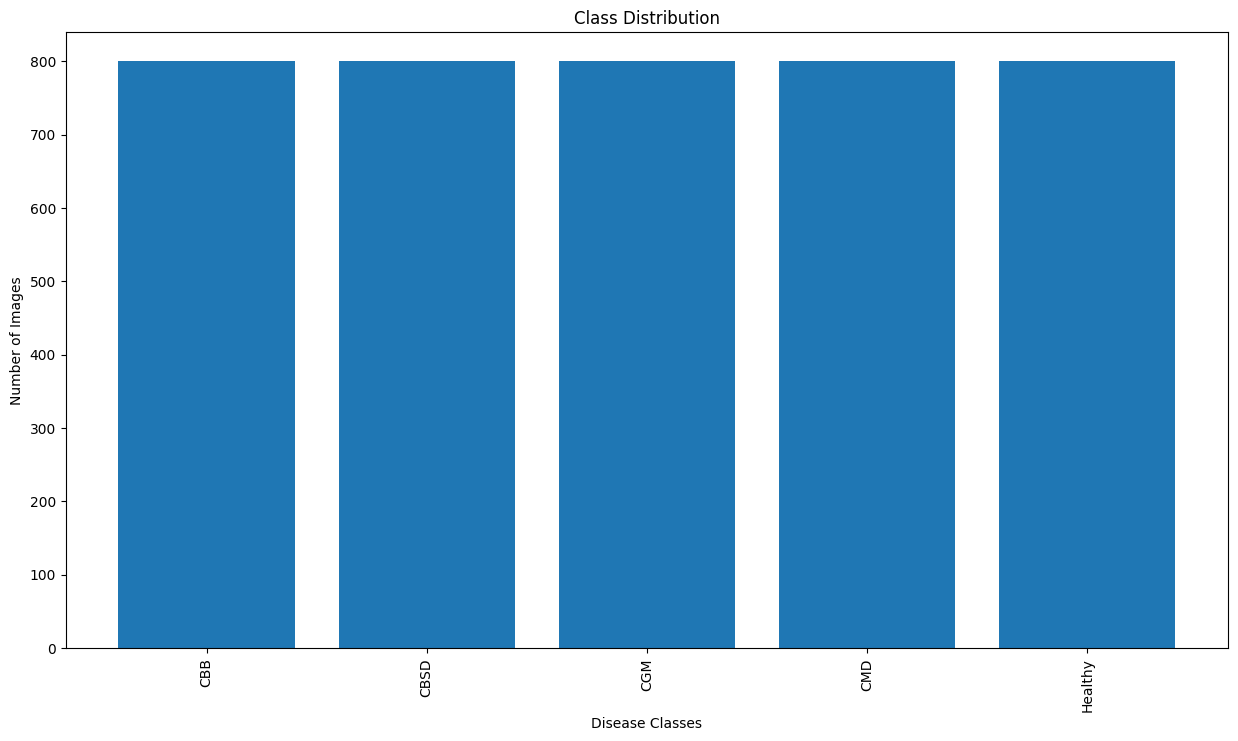

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plt.bar(names, values)

plt.xticks(rotation=90)

plt.title("Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")

plt.show()

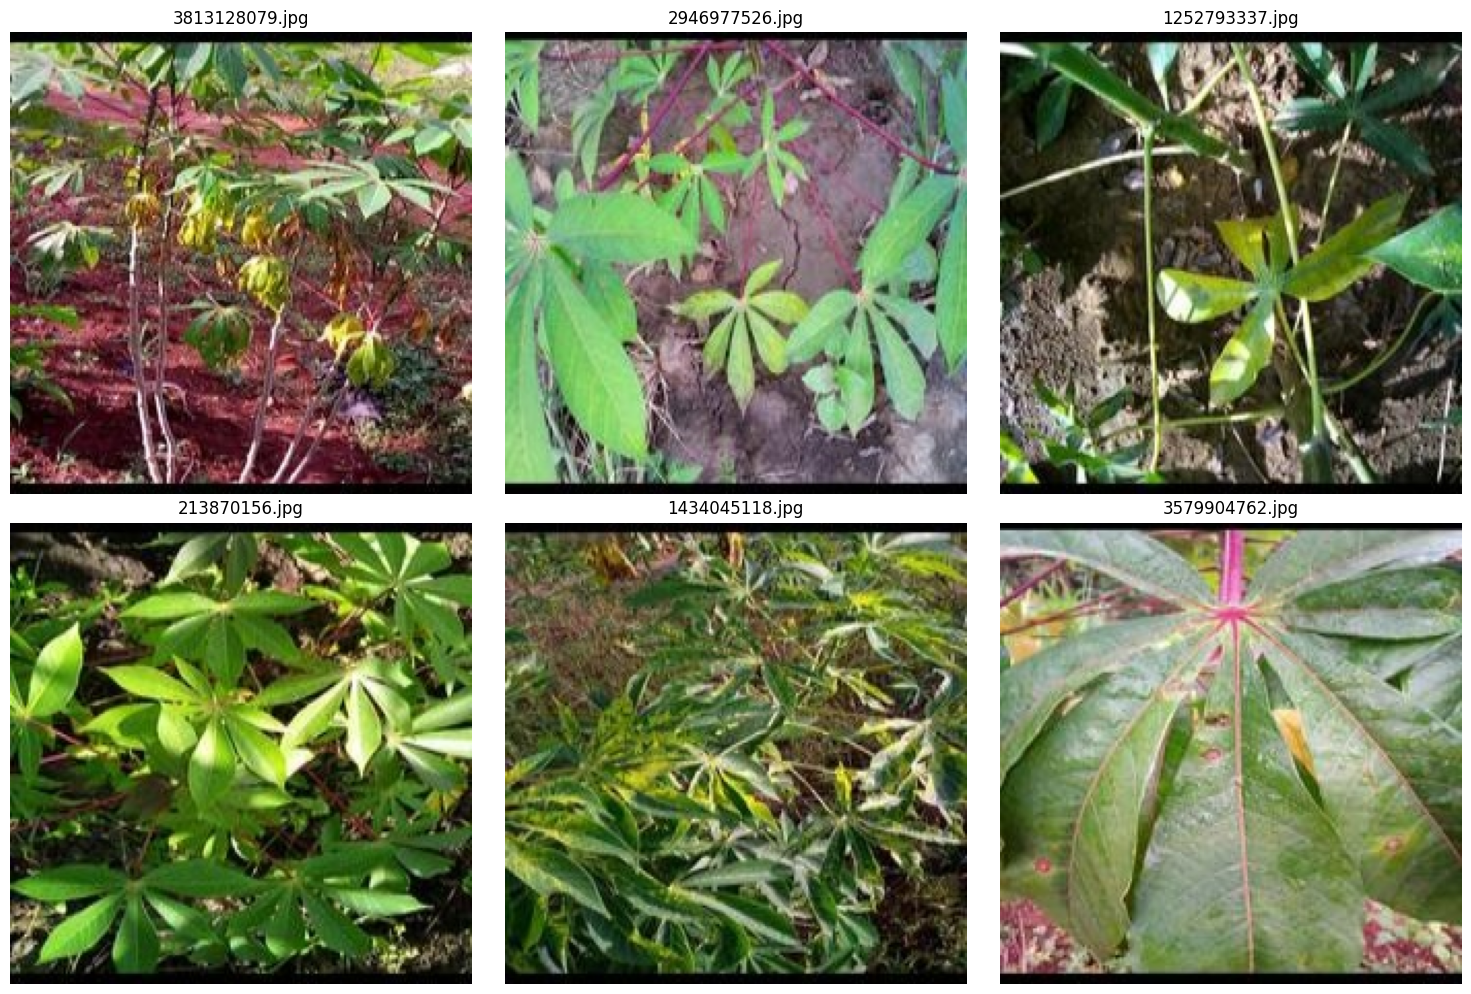

In [14]:
import matplotlib.pyplot as plt
import os
import cv2
import random

# =========================================================
# FOLDER PATH
# =========================================================

folder = "/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/"

# =========================================================
# GET IMAGE FILES
# =========================================================

files = [

    f for f in os.listdir(folder)

    if f.lower().endswith(
        ('.png', '.jpg', '.jpeg')
    )

]

# =========================================================
# RANDOMLY SELECT 6 IMAGES
# =========================================================

sample_files = random.sample(files, 6)

# =========================================================
# PLOT IMAGES
# =========================================================

plt.figure(figsize=(15,10))

for i, file in enumerate(sample_files):

    # Full image path
    img_path = os.path.join(folder, file)

    # Read image
    img = cv2.imread(img_path)

    # Convert BGR → RGB
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Plot image
    plt.subplot(2, 3, i+1)

    plt.imshow(img)

    plt.title(file)

    plt.axis("off")

plt.tight_layout()

plt.show()

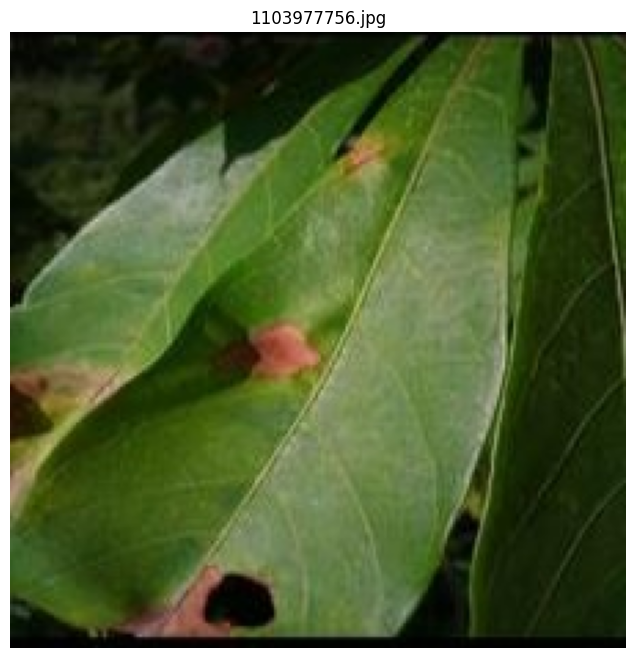

In [15]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# =========================================================
# FOLDER PATH
# =========================================================

folder = "/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/"

# =========================================================
# GET IMAGE FILES
# =========================================================

files = [

    f for f in os.listdir(folder)

    if f.lower().endswith(
        ('.png', '.jpg', '.jpeg')
    )

]

# =========================================================
# SELECT ONE RANDOM IMAGE
# =========================================================

file = random.choice(files)

# Full image path
img_path = os.path.join(folder, file)

# =========================================================
# READ IMAGE
# =========================================================

img = cv2.imread(img_path)

# Convert BGR → RGB
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# =========================================================
# DISPLAY IMAGE
# =========================================================

plt.figure(figsize=(8,8))

plt.imshow(img)

plt.title(file)

plt.axis("off")

plt.show()

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


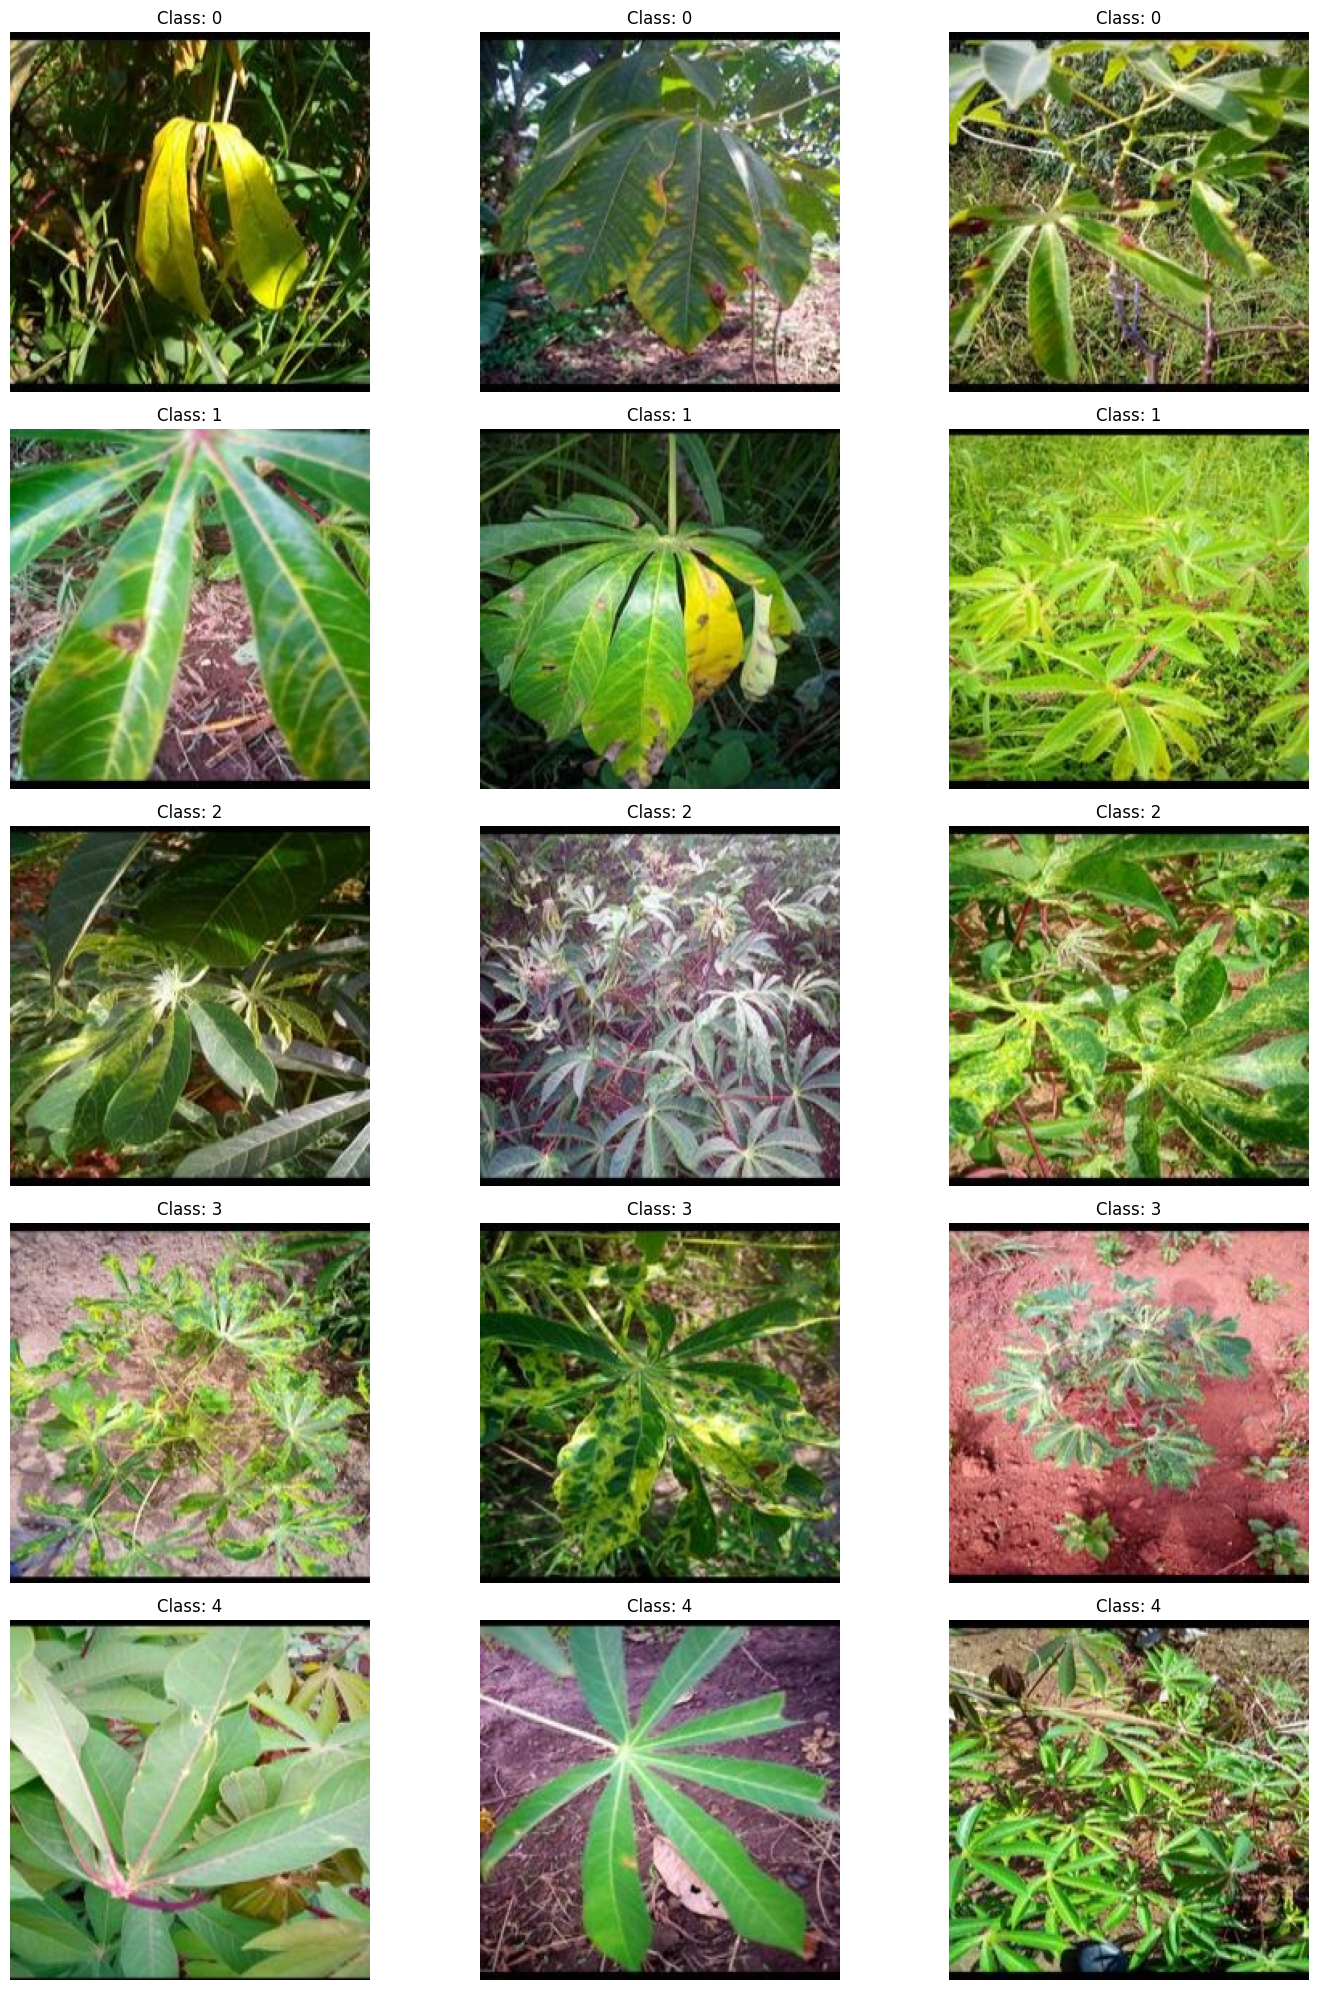

In [16]:
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd

# =========================================================
# IMAGE FOLDER
# =========================================================

folder = "/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/"

# =========================================================
# LOAD CSV
# =========================================================

train_csv_path = "/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train.csv"

train_df = pd.read_csv(train_csv_path)

# =========================================================
# GET UNIQUE CLASSES
# =========================================================

classes = sorted(train_df['Labels'].unique())

print("Classes:", classes)

# =========================================================
# CREATE FIGURE
# =========================================================

plt.figure(figsize=(15,20))

plot_index = 1

# =========================================================
# LOOP THROUGH EACH CLASS
# =========================================================

for cls in classes:

    # Get 3 images from this class
    class_images = train_df[
        train_df['Labels'] == cls
    ].sample(3, random_state=42)

    # =====================================================
    # SHOW IMAGES
    # =====================================================

    for _, row in class_images.iterrows():

        image_name = row['ID']

        img_path = os.path.join(
            folder,
            image_name
        )

        # Read image
        img = cv2.imread(img_path)

        # Convert BGR → RGB
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # Plot
        plt.subplot(
            len(classes),
            3,
            plot_index
        )

        plt.imshow(img)

        plt.title(f"Class: {cls}")

        plt.axis("off")

        plot_index += 1

# =========================================================
# SHOW IMAGES
# =========================================================

plt.tight_layout()

plt.show()

In [17]:
import tensorflow as tf
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================================================
# INSTALL TENSORFLOW HUB
# =========================================================

!pip install -q tensorflow-hub

import tensorflow_hub as hub

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization,
    Input
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# =========================================================
# LOAD EFFICIENTNET LITE1
# =========================================================

IMG_SIZE = 240

efficientnet_lite_url = (
    "https://tfhub.dev/tensorflow/efficientnet/lite1/feature-vector/2"
)

base_model = hub.KerasLayer(
    efficientnet_lite_url,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    trainable=True
)

I0000 00:00:1778864326.176217      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778864326.182160      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
train_dir = TRAIN_DIR

In [20]:
df = pd.read_csv(TRAIN_CSV)

In [21]:
train_df, val_df = train_test_split(

    df,

    test_size=0.2,

    random_state=42,

    stratify=df['Labels']
)

In [22]:
print(train_df.head())
print(val_df.head())
print(test_df.head())

                  ID  Labels
3552  2616538732.jpg       1
1183  1536703688.jpg       2
3649    61357519.jpg       4
3597  4266856745.jpg       1
1882   186394398.jpg       0
                  ID  Labels
1327  4050718274.jpg       2
1040  4159778976.jpg       3
1920  2055911260.jpg       2
3212  3116498490.jpg       0
164   3854553332.jpg       4
               ID  Labels
0  2595356168.jpg       3
1   794817264.jpg       0
2  4270972443.jpg       4
3  3540803278.jpg       0
4  2142522228.jpg       3


In [23]:
train_df['Labels'] = train_df['Labels'].astype(str)
val_df['Labels'] = val_df['Labels'].astype(str)
test_df['Labels'] = test_df['Labels'].astype(str)

print("--- After label type conversion ---")
print("train_df Labels dtype:", train_df['Labels'].dtype)
print("train_df Labels unique values:", train_df['Labels'].unique())
print("train_df Labels value counts:\n", train_df['Labels'].value_counts())
print("\nval_df Labels dtype:", val_df['Labels'].dtype)
print("val_df Labels unique values:", val_df['Labels'].unique())
print("val_df Labels value counts:\n", val_df['Labels'].value_counts())
print("\ntest_df Labels dtype:", test_df['Labels'].dtype)
print("test_df Labels unique values:", test_df['Labels'].unique())
print("test_df Labels value counts:\n", test_df['Labels'].value_counts())

--- After label type conversion ---
train_df Labels dtype: object
train_df Labels unique values: ['1' '2' '4' '0' '3']
train_df Labels value counts:
 Labels
1    640
2    640
4    640
0    640
3    640
Name: count, dtype: int64

val_df Labels dtype: object
val_df Labels unique values: ['2' '3' '0' '4' '1']
val_df Labels value counts:
 Labels
2    160
3    160
0    160
4    160
1    160
Name: count, dtype: int64

test_df Labels dtype: object
test_df Labels unique values: ['3' '0' '4' '2' '1']
test_df Labels value counts:
 Labels
3    200
0    200
4    200
2    200
1    200
Name: count, dtype: int64


In [24]:
print(train_df.dtypes)
print(val_df.dtypes)
print(test_df.dtypes)

ID        object
Labels    object
dtype: object
ID        object
Labels    object
dtype: object
ID        object
Labels    object
dtype: object


In [25]:
from sklearn.model_selection import train_test_split

# =========================================================
# RANDOM SEED
# =========================================================

SEED = 42

# =========================================================
# TRAIN VALIDATION SPLIT
# =========================================================

train_split_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['Labels']
)

# =========================================================
# DISPLAY COUNTS
# =========================================================

print('Train Images :', len(train_split_df))
print('Validation Images :', len(val_df))
print('Test Images :', len(test_df))

Train Images : 2560
Validation Images : 640
Test Images : 1000


In [26]:

IMG_SIZE = 240
BATCH_SIZE = 32

In [27]:
import os

print(os.listdir(train_dir)[:5])

['1058931181.jpg', '688489193.jpg', '3507045403.jpg', '137128883.jpg', '495897960.jpg']


In [28]:
sample_image = train_df.iloc[0]['ID']

image_path = os.path.join(train_dir, sample_image)

print(image_path)

print(os.path.exists(image_path))

/kaggle/input/datasets/aliyachomo/plant-villegedataset//Train_Images_clean/2616538732.jpg
True


In [29]:
print(test_df.head())

               ID Labels
0  2595356168.jpg      3
1   794817264.jpg      0
2  4270972443.jpg      4
3  3540803278.jpg      0
4  2142522228.jpg      3


In [30]:
sample_test = test_df.iloc[0]['ID']

import os

print(sample_test)

print(os.path.join(train_dir, sample_test))

print(os.path.exists(os.path.join(train_dir, sample_test)))

2595356168.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset//Train_Images_clean/2595356168.jpg
False


In [31]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [32]:
# =========================================================
# EFFICIENTNETLITE1 DATA GENERATOR SETUP
# =========================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# EfficientNet preprocessing
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================================================
# CONVERT LABELS TO STRING
# =========================================================

train_df['Labels'] = train_df['Labels'].astype(str)

val_df['Labels'] = val_df['Labels'].astype(str)

# Only if test labels exist
if 'Labels' in test_df.columns:
    test_df['Labels'] = test_df['Labels'].astype(str)

# =========================================================
# IMAGE SIZE FOR EfficientNetLite1
# =========================================================

IMG_SIZE = 240

# =========================================================
# TRAIN DATA GENERATOR
# =========================================================

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.1,

    height_shift_range=0.1,

    shear_range=0.1,

    horizontal_flip=True,

    fill_mode='nearest'

)

# =========================================================
# VALIDATION / TEST GENERATOR
# =========================================================

valid_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input

)

# =========================================================
# TRAIN GENERATOR
# =========================================================

train_generator = train_datagen.flow_from_dataframe(

    dataframe=train_df,

    directory=TRAIN_DIR,

    x_col='ID',

    y_col='Labels',

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=True,

    seed=SEED

)

# =========================================================
# VALIDATION GENERATOR
# =========================================================

valid_generator = valid_datagen.flow_from_dataframe(

    dataframe=val_df,

    directory=TRAIN_DIR,

    x_col='ID',

    y_col='Labels',

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False

)

# =========================================================
# TEST GENERATOR
# =========================================================

# If test labels are NOT available
if 'Labels' not in test_df.columns:

    test_generator = valid_datagen.flow_from_dataframe(

        dataframe=test_df,

        directory=TEST_DIR,

        x_col='ID',

        y_col=None,

        target_size=(IMG_SIZE, IMG_SIZE),

        batch_size=BATCH_SIZE,

        class_mode=None,

        shuffle=False

    )

# If test labels ARE available
else:

    test_generator = valid_datagen.flow_from_dataframe(

        dataframe=test_df,

        directory=TEST_DIR,

        x_col='ID',

        y_col='Labels',

        target_size=(IMG_SIZE, IMG_SIZE),

        batch_size=BATCH_SIZE,

        class_mode='categorical',

        shuffle=False

    )

# =========================================================
# CHECK CLASS INFO
# =========================================================

print("Class Indices:")
print(train_generator.class_indices)

print("Number of Classes:")
print(len(train_generator.class_indices))

Found 3200 validated image filenames belonging to 5 classes.
Found 640 validated image filenames belonging to 5 classes.
Found 1000 validated image filenames belonging to 5 classes.
Class Indices:
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Number of Classes:
5


In [33]:
# Install TensorFlow Hub
!pip install -q tensorflow-hub

In [34]:
!pip install -q efficientnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.1 MB/s eta 0:00:00


In [35]:
x_batch, y_batch = next(train_generator)

print("Image batch shape:", x_batch.shape)

print("Label batch shape:", y_batch.shape)

print(y_batch[:5])

Image batch shape: (32, 240, 240, 3)
Label batch shape: (32, 5)
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [36]:
print(train_generator.class_indices)

print("Number of classes:",
      train_generator.num_classes)

print("Class mode:",
      train_generator.class_mode)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


AttributeError: 'DataFrameIterator' object has no attribute 'num_classes'

In [37]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [40]:
!pip install -q tensorflow-hub

In [43]:
!wget https://github.com/sebastian-sz/efficientnet-lite-keras-weights/releases/download/v1.0/efficientnet-lite1.h5

--2026-05-15 17:04:54--  https://github.com/sebastian-sz/efficientnet-lite-keras-weights/releases/download/v1.0/efficientnet-lite1.h5
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-15 17:04:54 ERROR 404: Not Found.



In [50]:
!pip install -q efficientnet-lite

ERROR: Could not find a version that satisfies the requirement efficientnet-lite (from versions: none)
ERROR: No matching distribution found for efficientnet-lite


In [54]:
# =========================================================
# IMPORTS
# =========================================================
# =========================================================
# IMPORTS
# =========================================================

import tensorflow as tf
import tensorflow_hub as hub
!pip install -q efficientnet-lite

from tensorflow.keras.applications import EfficientNetB1 as EfficientNetLite1

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.optimizers import Adam

#load pretrained model

# =========================================================
# LOAD EfficientNetLite1 MODEL
# =========================================================


base_model = EfficientNetLite1(

    weights='imagenet',

    include_top=False,

    input_shape=(240,240,3)
)
#loads pretrained model base
base_model.load_weights(
    "/kaggle/input/datasets/aliyachomo/efficientnetlite1/efficientnet-lite1/efficientnet-lite1-fp32.tflite"
)


# =========================================================
# FINE TUNING
# =========================================================

base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# =========================================================
# CUSTOM HEAD
# =========================================================


# =========================================================

# =========================================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.2)(x)

output = Dense(

    len(train_generator.class_indices),

    activation='softmax'

)(x)

# =========================================================
# FINAL MODEL
# =========================================================

model = Model(

    inputs=base_model.input,

    outputs=outputs

)

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()

ERROR: Could not find a version that satisfies the requirement efficientnet-lite (from versions: none)
ERROR: No matching distribution found for efficientnet-lite


ValueError: File format not supported: filepath=/kaggle/input/datasets/aliyachomo/efficientnetlite1/efficientnet-lite1/efficientnet-lite1-fp32.tflite. Keras 3 only supports V3 `.keras` and `.weights.h5` files, or legacy V1/V2 `.h5` files.

In [55]:
# =========================================================
# LOAD EfficientNetLite1 MODEL
# =========================================================

base_model = EfficientNetLite1(

    weights='imagenet',

    include_top=False,

    input_shape=(240,240,3)

)

print("Pretrained Weights Loaded Successfully!")

Pretrained Weights Loaded Successfully!


In [56]:
# =========================================================
# FINE TUNING
# =========================================================

base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# =========================================================
# CUSTOM HEAD
# =========================================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.2)(x)

output = Dense(

    len(train_generator.class_indices),

    activation='softmax'

)(x)

# =========================================================
# FINAL MODEL
# =========================================================

model = Model(

    inputs=base_model.input,

    outputs=output

)

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(

    optimizer=Adam(learning_rate=1e-4),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 240, 240,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 240, 240,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 240, 240,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,941,836 (26.48 MB)

 Trainable params: 2,709,077 (10.33 MB)

 Non-trainable params: 4,232,759 (16.15 MB)

In [57]:
# =========================================================
# IMPORT CALLBACKS
# =========================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# =========================================================
# EARLY STOPPING
# =========================================================

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=5,

    restore_best_weights=True,

    verbose=1

)

# =========================================================
# REDUCE LEARNING RATE
# =========================================================

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.3,

    patience=2,

    min_lr=1e-6,

    verbose=1

)

# =========================================================
# MODEL CHECKPOINT
# =========================================================

checkpoint = ModelCheckpoint(

    filepath="/kaggle/working/best_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    mode='max',

    verbose=1

)

# =========================================================
# CALLBACK LIST
# =========================================================

callbacks = [

    early_stop,

    reduce_lr,

    checkpoint

]

print("Callbacks Ready 🚀")

Callbacks Ready 🚀


In [58]:
history = model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=30,

    callbacks=callbacks

)

Epoch 1/30


I0000 00:00:1778865677.476319     141 service.cc:152] XLA service 0x78d88c004a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778865677.476368     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778865677.476372     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778865681.066738     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 17:21:31.329387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 17:21:31.473963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 17:21:31.828596: E external/local_xl

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.2798 - loss: 1.8522
Epoch 1: val_accuracy improved from -inf to 0.50313, saving model to /kaggle/working/best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 117s 715ms/step - accuracy: 0.2804 - loss: 1.8503 - val_accuracy: 0.5031 - val_loss: 1.3239 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.4263 - loss: 1.4084
Epoch 2: val_accuracy improved from 0.50313 to 0.56563, saving model to /kaggle/working/best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 419ms/step - accuracy: 0.4265 - loss: 1.4080 - val_accuracy: 0.5656 - val_loss: 1.1474 - learning_rate: 1.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.4806 - loss: 1.2815
Epoch 3: val_accuracy improved from 0.56563 to 0.62813, saving model to /kaggle/working/best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.4808 - loss: 1.2811 - val_accuracy: 0.6281 - val_loss: 0.9847 - learning_rate: 1

In [60]:
loss, accuracy = model.evaluate(valid_generator)

print("Final Validation Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8992 - loss: 0.2685
Final Validation Accuracy: 0.890625


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step

ACCURACY
Accuracy: 0.8906

PRECISION
Precision: 0.8967

RECALL
Recall: 0.8906

F1 SCORE
F1 Score: 0.8917

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       128
           1       0.86      0.94      0.90       128
           2       0.79      0.90      0.84       128
           3       0.96      0.85      0.90       128
           4       0.90      0.87      0.88       128

    accuracy                           0.89       640
   macro avg       0.90      0.89      0.89       640
weighted avg       0.90      0.89      0.89       640



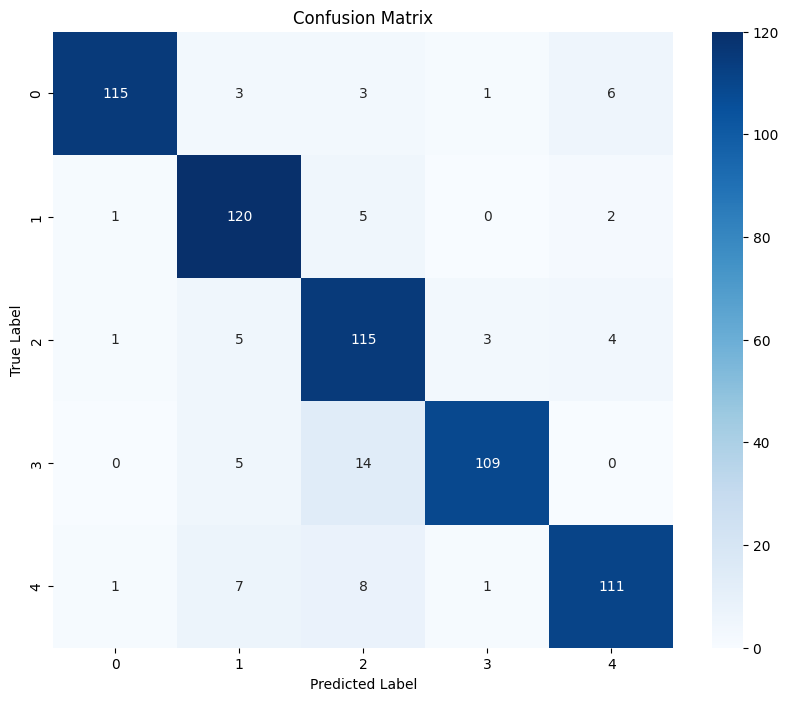

In [61]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

# =========================================================
# RESET GENERATOR
# IMPORTANT BEFORE PREDICTION
# =========================================================

valid_generator.reset()

# =========================================================
# MODEL PREDICTIONS
# =========================================================

pred_probs = model.predict(
    valid_generator,
    verbose=1
)

# Convert probabilities to class index
pred_classes = np.argmax(
    pred_probs,
    axis=1
)

# True labels
true_classes = valid_generator.classes

# =========================================================
# ACCURACY
# =========================================================

accuracy = accuracy_score(
    true_classes,
    pred_classes
)

print("\n==============================")
print("ACCURACY")
print("==============================")

print(f"Accuracy: {accuracy:.4f}")

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    true_classes,
    pred_classes,
    average='weighted'
)

print("\n==============================")
print("PRECISION")
print("==============================")

print(f"Precision: {precision:.4f}")

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    true_classes,
    pred_classes,
    average='weighted'
)

print("\n==============================")
print("RECALL")
print("==============================")

print(f"Recall: {recall:.4f}")

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    true_classes,
    pred_classes,
    average='weighted'
)

print("\n==============================")
print("F1 SCORE")
print("==============================")

print(f"F1 Score: {f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

class_names = list(
    valid_generator.class_indices.keys()
)

print(classification_report(

    true_classes,

    pred_classes,

    target_names=class_names

))

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    true_classes,
    pred_classes
)

# =========================================================
# PLOT CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [62]:
from sklearn.metrics import classification_report
import numpy as np

# Predictions
pred_probs = model.predict(valid_generator)

predictions = np.argmax(pred_probs, axis=1)

# True labels
true_labels = valid_generator.classes

# Report
print(classification_report(
    true_labels,
    predictions
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       128
           1       0.86      0.94      0.90       128
           2       0.79      0.90      0.84       128
           3       0.96      0.85      0.90       128
           4       0.90      0.87      0.88       128

    accuracy                           0.89       640
   macro avg       0.90      0.89      0.89       640
weighted avg       0.90      0.89      0.89       640



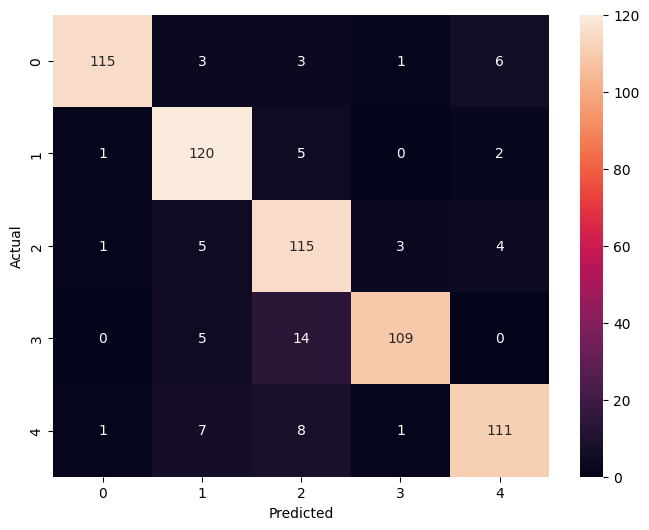

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [64]:
model.save(
    "/kaggle/working/plant_disease_model.keras"
)

In [65]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aliyachomo/plant-villegedataset/label_num_to_disease_map.json
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train.csv
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test.csv
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1235188286.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1563395006.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1589421421.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1877332484.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/2319781928.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/1058931181.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/688489193.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/3507045403.jpg
/kaggle/input/datasets/aliyachomo/plant-villegedataset/Train_Images_clean/137128

In [66]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# =========================================================
# IMAGE PATH
# =========================================================

img_path = "/kaggle/input/datasets/aliyachomo/plant-villegedataset/Test_Images_clean/1786966899.jpg"

# =========================================================
# GET IMAGE NAME
# =========================================================

image_name = os.path.basename(img_path)

# =========================================================
# GET ACTUAL LABEL FROM DATAFRAME
# =========================================================

# Make sure test_df is already loaded

actual_label = test_df.loc[
    test_df['ID'] == image_name,
    'Labels'
].values[0]

# =========================================================
# LOAD IMAGE
# =========================================================

img = image.load_img(
    img_path,
    target_size=(224,224)
)

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# EfficientNet preprocessing
img_array = preprocess_input(img_array)

# =========================================================
# PREDICTION
# =========================================================

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

# =========================================================
# DISPLAY IMAGE
# =========================================================

plt.figure(figsize=(6,6))

# Reload image for display
display_img = image.load_img(img_path)

plt.imshow(display_img)

plt.title(

    f"Actual Label: {actual_label}\n"
    
    f"Predicted Label: {predicted_class}\n"
    
    f"Confidence: {confidence:.2f}"

)

plt.axis('off')

plt.show()

ValueError: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 240, 240, 3), found shape=(1, 224, 224, 3)

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

import matplotlib.pyplot as plt
import numpy as np
import os
import random

# =========================================================
# SELECT 10 RANDOM IMAGES
# =========================================================

sample_df = test_df.sample(10, random_state=42)

# =========================================================
# CREATE FIGURE
# =========================================================

plt.figure(figsize=(20,20))

# =========================================================
# LOOP THROUGH IMAGES
# =========================================================

for i, row in enumerate(sample_df.itertuples(), 1):

    # Image filename
    image_name = row.ID

    # Actual label
    actual_label = str(row.Labels)

    # Full image path
    img_path = os.path.join(
        TEST_DIR,
        image_name
    )

    # =====================================================
    # LOAD IMAGE
    # =====================================================

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    # Convert image to array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # EfficientNet preprocessing
    img_array = preprocess_input(img_array)

    # =====================================================
    # PREDICTION
    # =====================================================

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_class = str(
        np.argmax(prediction)
    )

    confidence = np.max(prediction)

    # =====================================================
    # DISPLAY IMAGE
    # =====================================================

    plt.subplot(5, 2, i)

    display_img = image.load_img(img_path)

    plt.imshow(display_img)

    # =====================================================
    # TITLE
    # =====================================================

    color = "green"

    if actual_label != predicted_class:
        color = "red"

    plt.title(

        f"Actual: {actual_label}\n"
        
        f"Predicted: {predicted_class}\n"
        
        f"Confidence: {confidence:.2f}",

        color=color,

        fontsize=10

    )

    plt.axis('off')

# =========================================================
# SHOW ALL IMAGES
# =========================================================

plt.tight_layout()

plt.show()

In [ ]:
import tensorflow as tf

# =========================================================
# LOAD BEST MODEL
# =========================================================

model = tf.keras.models.load_model(
    "/kaggle/working/best_model.keras"
)

# =========================================================
# CONVERT TO TFLITE
# =========================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert model
tflite_model = converter.convert()

# =========================================================
# SAVE TFLITE MODEL
# =========================================================

with open(
    "/kaggle/working/plant_disease_model.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("TFLite Model Saved Successfully 🚀")